# Análisis y Procesamiento de datos (tabulares y volúmenes)
 - Limpieza básica: ortografía, mismos conceptos médicos con diferentes palabras (hecho sobre el csv de los datos)
 - Estadísticas descriptivas
 - Análisis exploratorio con gráficos
 - Análisis de los volumenes DICOM

In [1]:
# importaciones de librerías
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # para servidores sin entorno gráfico
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
#para eda de los volumenes
import pydicom
from pydicom.filereader import dcmread
import scipy.ndimage
from collections import Counter

Vamos a hacer una analisis de datos tanto de los datos tabulares (datos clinicos) como de los volumenes originales dicom. 

In [1]:
# configuración general 
sns.set_palette("pastel")
%matplotlib inline

In [4]:
# cargamos los datos clínicos
df = pd.read_csv("./../../clinical_data/clinical_data.csv", na_values="NaN", sep=",")
print(f"Datos cargados. Shape: {df.shape}")

Datos cargados. Shape: (203, 8)


## Análisis de los volúmenes DICOM

In [ ]:
DICOM_DIR = "./../../volumenes/datos_anonimizados/" 

In [20]:
pacientes = [os.path.join(DICOM_DIR, p) for p in os.listdir(DICOM_DIR) if os.path.isdir(os.path.join(DICOM_DIR, p))]
print(f"Pacientes detectados: {len(pacientes)}")

Pacientes detectados: 125


In [21]:
resumen_dicom = [] #vamos a ir guardando un resumen de los volúmenes

Vamos a guardar toda la información que nos aporta un dicom, para ello cogeremos un al azar. 

In [22]:
#recorremos todos los pacientes
for paciente_path in pacientes:
    paciente_id = os.path.basename(paciente_path)

    # Recorremos todas subcarpetas y contar todos los archivos
    slices_paths = []
    for root, dirs, files in os.walk(paciente_path):
        for f in files:
            slices_paths.append(os.path.join(root, f))

    num_slices = len(slices_paths)
    if num_slices == 0:
        print(f" {paciente_id} no tiene slices encontrados.")
        continue

    # leemos solo una slice como ejemplo
    ejemplo_path = slices_paths[0] 
    try:
        ds = dcmread(ejemplo_path) 
        shape = ds.pixel_array.shape
        spacing = getattr(ds, "PixelSpacing", ["NA","NA"]) 
        thickness = getattr(ds, "SliceThickness", "NA")
    except Exception as e:
        print(f" Error leyendo ejemplo en {paciente_id}: {e}")
        shape = ("Error","Error")
        spacing = ("NA","NA")
        thickness = "NA"

    # Guardamos el resumen del paciente
    resumen_dicom.append({
        "Paciente": paciente_id,
        "Num_slices": num_slices,
        "Height": shape[0],
        "Width": shape[1],
        "Spacing_X": spacing[0],
        "Spacing_Y": spacing[1],
        "Spacing_Z": thickness
    })

 Error leyendo ejemplo en 92MASN: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
 Error leyendo ejemplo en 93HESN: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
 Error leyendo ejemplo en 94HCNSN: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
 Error leyendo ejemplo en 95HASH: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
 Error leyendo ejemplo en 100HNnSNH: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.


Dan 5 pacientes errores pero es por lo dicoms, cuando los pasemos a nifti ya no dan error. 


 Resumen de volúmenes DICOM:


,Paciente,Num_slices,Height,Width,Spacing_X,Spacing_Y,Spacing_Z
0,10MANX,292,768,768,0.375,0.375,1.0
1,11HASh,223,512,512,0.660156,0.660156,1.25
2,12HNSN,364,768,768,0.458333,0.458333,2.0
3,13HANX,259,512,512,0.78125,0.78125,1.25
4,15MANX,229,512,512,0.685547,0.685547,1.25
...,...,...,...,...,...,...,...
120,97HASN,287,768,768,0.47526,0.47526,1.0
121,98HESN,601,512,512,0.976562,0.976562,1.0
122,99MASH,193,512,512,0.78125,0.78125,1.25
123,74HCeNX,407,512,512,0.976562,0.976562,2.0



 Distribución de tamaños (Num_slices, Height, Width):
(292, 768, 768): 1 volúmenes
(223, 512, 512): 1 volúmenes
(364, 768, 768): 1 volúmenes
(259, 512, 512): 1 volúmenes
(229, 512, 512): 1 volúmenes
(300, 768, 768): 2 volúmenes
(220, 512, 512): 4 volúmenes
(215, 512, 512): 1 volúmenes
(67, 512, 512): 1 volúmenes
(271, 768, 768): 1 volúmenes
(545, 768, 768): 1 volúmenes
(231, 512, 512): 1 volúmenes
(54, 768, 768): 1 volúmenes
(208, 512, 512): 1 volúmenes
(301, 768, 768): 1 volúmenes
(291, 768, 768): 1 volúmenes
(327, 768, 768): 1 volúmenes
(2, 768, 768): 1 volúmenes
(296, 768, 768): 2 volúmenes
(222, 768, 768): 1 volúmenes
(463, 512, 512): 1 volúmenes
(328, 512, 512): 1 volúmenes
(609, 768, 768): 1 volúmenes
(222, 512, 512): 2 volúmenes
(286, 768, 768): 1 volúmenes
(51, 768, 768): 1 volúmenes
(290, 768, 768): 1 volúmenes
(473, 512, 512): 1 volúmenes
(285, 768, 768): 2 volúmenes
(303, 768, 768): 3 volúmenes
(488, 512, 512): 1 volúmenes
(174, 512, 512): 1 volúmenes
(151, 512, 512): 2 vol

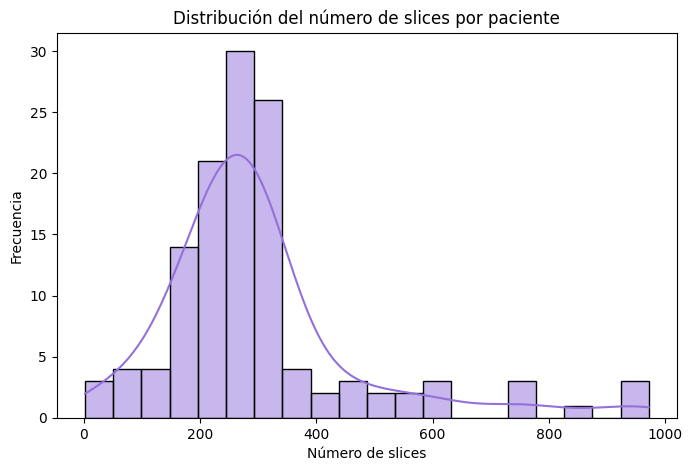


 Distribución de resoluciones (Height, Width) en el dataset:
(Height 512, Width 512): 70 volúmenes
(Height 768, Width 768): 50 volúmenes
(Height Error, Width Error): 5 volúmenes


In [23]:
if resumen_dicom:
    df_resumen = pd.DataFrame(resumen_dicom)
    print("\n Resumen de volúmenes DICOM:")
    display(df_resumen)

    # Distribución de shapes
    shapes_list = list(zip(df_resumen["Num_slices"], df_resumen["Height"], df_resumen["Width"]))
    from collections import Counter
    shapes_counter = Counter(shapes_list)
    print("\n Distribución de tamaños (Num_slices, Height, Width):")
    for shape, count in shapes_counter.items():
        print(f"{shape}: {count} volúmenes")

    # Histograma del número de slices
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_palette("pastel")
    plt.figure(figsize=(8,5))
    sns.histplot(df_resumen["Num_slices"], bins=20, kde=True, color="mediumpurple")
    plt.title("Distribución del número de slices por paciente")
    plt.xlabel("Número de slices")
    plt.ylabel("Frecuencia")
    plt.show()

    print("\n Distribución de resoluciones (Height, Width) en el dataset:")

    # Agrupamos y contamos
    resoluciones_counter = df_resumen.groupby(['Height', 'Width']).size().reset_index(name='Count')

    for idx, row in resoluciones_counter.iterrows():
        print(f"(Height {row['Height']}, Width {row['Width']}): {row['Count']} volúmenes")

else:
    print("\n No se generó resumen: no se encontraron volúmenes válidos.")

Vamos a comentar primero el resumen de los volumenes DICOM. Podemos observar como tneemos 125 pacientes y 7 columnas. Los pacientes son unívocos. Tenemos de cada paciente el número de slices que tiene cada volumen, es decir, la profundidad del volumen. Es muy variado, por lo que habrá que preprocesarlo. También se puede observar las dimensiones de altura y anchura. Los valores típicos en una CT es 512x512, el cual lo vemos en nuestros volúmenes, pero también vemos otro tipo que es el tamaño 768x758. Esto se debe a que el propio hospital tiene varias máquinas y dependiendo de la máquina que se haga la prueba puede variar la dimensionalidad del volumen. Después tenemos los espacion físicos en los tres ejes donde podemos ver que no es uniforme. Esto es importante para sacar radiómicas. 

Con respecto al histograma de la distribución del número de slices por paciente, tenemos en el eje X el número de slices y en el eje y la frecuencia, es decir, cuantos pacientes tienen esa cantidad de cortes.

Observamos como es una distribución asimétrica donde hay sesgo a la derecha, es decir, hacia más cantidad de slices. El pico principal está entre las 200 y las 300. Hay un paciente que llega a tener sobre unas 900 slices, poría considerarse un outlier. 

El dataset tiene dos tamaños de alto y ancho: 512x512 y 768x768 (sin contar el número de slices). Lo más logico va a ser reescalar y quedarnos con un tamaño fijo de 512x512. Se verá más en detalle en el apartado de preprocesamiento. 

Esta alta variabilidad habrá que tratarla con cuidad en el preprocesamiento ya que en una CNN 3D, los volúmenes de entrada deben tener un tamaño fijo, por lo que no se puede entrenar directamente con pacientes que tienen diferente número de slices. Este es nuestro caso, por lo que tenemos que aplicar alguna técnica para poder arreglar este problema.

Viendo el histograma de número de slices por pacientes, voy a empezar por la técnica de poner un número fijo de slices por pacientes. Los pacientes que les sobre slices, nos quedaremos con las centrales donde habrá más información. Los que les falten slices, vamos a hacer interpolación lineal (podriamos probar tambien con la bilineal). 